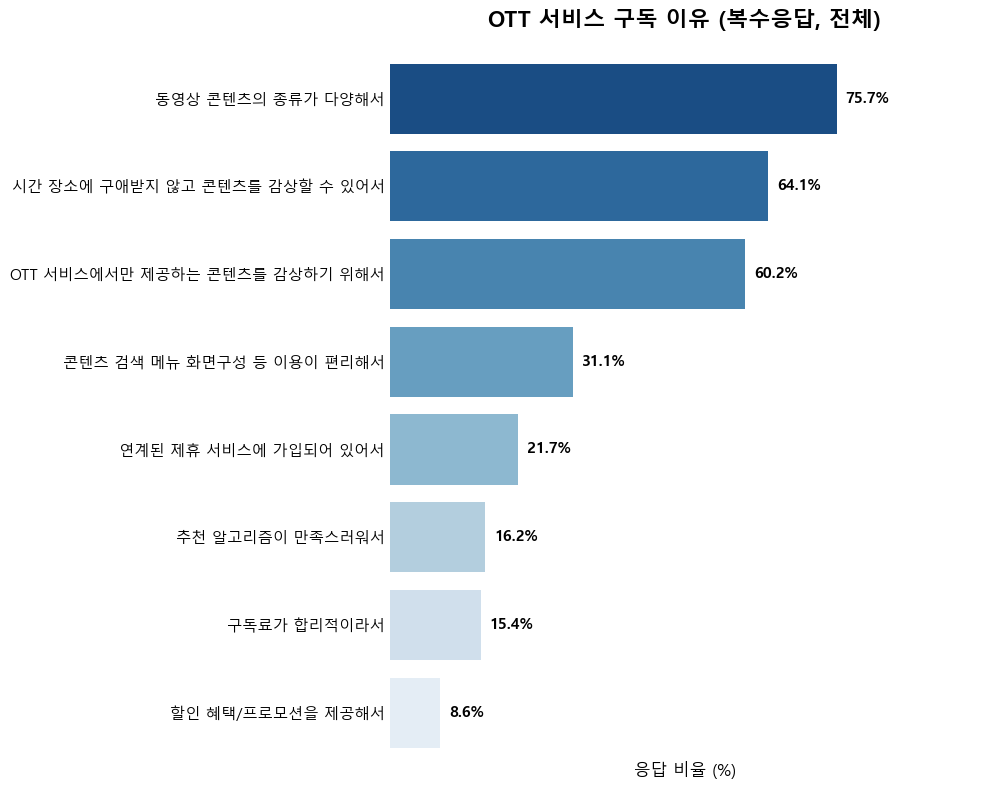

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 환경 (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기 (두 번째 줄을 헤더로 인식)
file_path = 'OTT_구독_이유_복수응답__20260409164000.csv'

try:
    df = pd.read_csv(file_path, header=1, encoding='utf-8-sig')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, header=1, encoding='cp949')

# 3. '전체' 데이터 추출 및 전처리
# '특성별(1)'이 '전체'인 행만 가져옵니다.
df_total = df[df['특성별(1)'] == '전체'].copy()

# 시각화에 불필요한 '특성별(1)', '사례수 (명)' 컬럼과 함께 '기타 (%)' 항목도 제외합니다.
df_reasons = df_total.drop(columns=['특성별(1)', '사례수 (명)', '기타 (%)'])

# 가로로 나열된 데이터를 세로(항목, 비율)로 변환 (Melt)
df_melted = df_reasons.melt(var_name='구독 이유', value_name='비율(%)')

# Y축 라벨이 깔끔하게 보이도록 문자열 끝의 ' (%)' 텍스트 제거
df_melted['구독 이유'] = df_melted['구독 이유'].str.replace(' \(%\)', '', regex=True).str.replace(' (%)', '', regex=False)

# 응답 비율이 높은 순서대로 내림차순 정렬
df_melted = df_melted.sort_values(by='비율(%)', ascending=False)

# 4. 그래프 그리기 설정
plt.figure(figsize=(10, 8)) # 항목 텍스트가 길고 많으므로 세로 길이를 충분히 줍니다.

# 가로 막대 그래프 생성 (FutureWarning 해결을 위해 hue와 legend=False를 추가)
ax = sns.barplot(data=df_melted, x='비율(%)', y='구독 이유', hue='구독 이유', palette='Blues_r', legend=False)

# 5. 그래프 디자인 및 꾸미기
# X축 범위를 0~100으로 설정 (복수응답이므로 개별 비율의 최대치는 100%)
ax.set_xlim(0, 100)

# 막대 끝에 수치(텍스트) 표기
for p in ax.patches:
    width = p.get_width()
    if pd.notnull(width) and width > 0:
        # 막대 오른쪽 끝에서 약간(1.5) 떨어진 곳에 텍스트 표시
        ax.text(width + 1.5, 
                p.get_y() + p.get_height() / 2, 
                f'{width:.1f}%', 
                ha='left', 
                va='center', 
                fontsize=11, 
                fontweight='bold')

# 축 및 테두리 정리
plt.title('OTT 서비스 구독 이유 (복수응답, 전체)', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('응답 비율 (%)', fontsize=12)
plt.ylabel('') # Y축 제목은 항목 자체가 설명하므로 생략

# 위, 오른쪽, 아래 테두리 및 X축 눈금 제거하여 깔끔하게 표시
sns.despine(left=True, bottom=True)
ax.set_xticks([]) 
ax.tick_params(axis='y', length=0, labelsize=11)

plt.tight_layout()
plt.show()

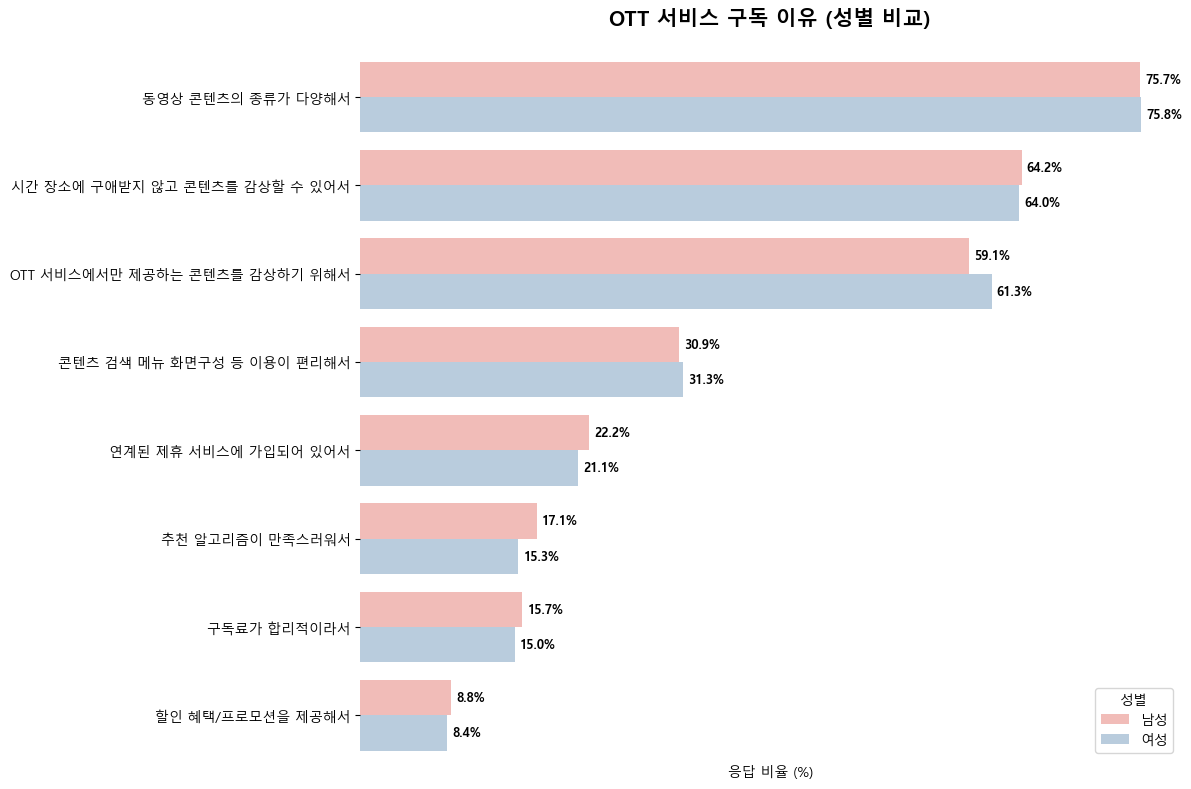

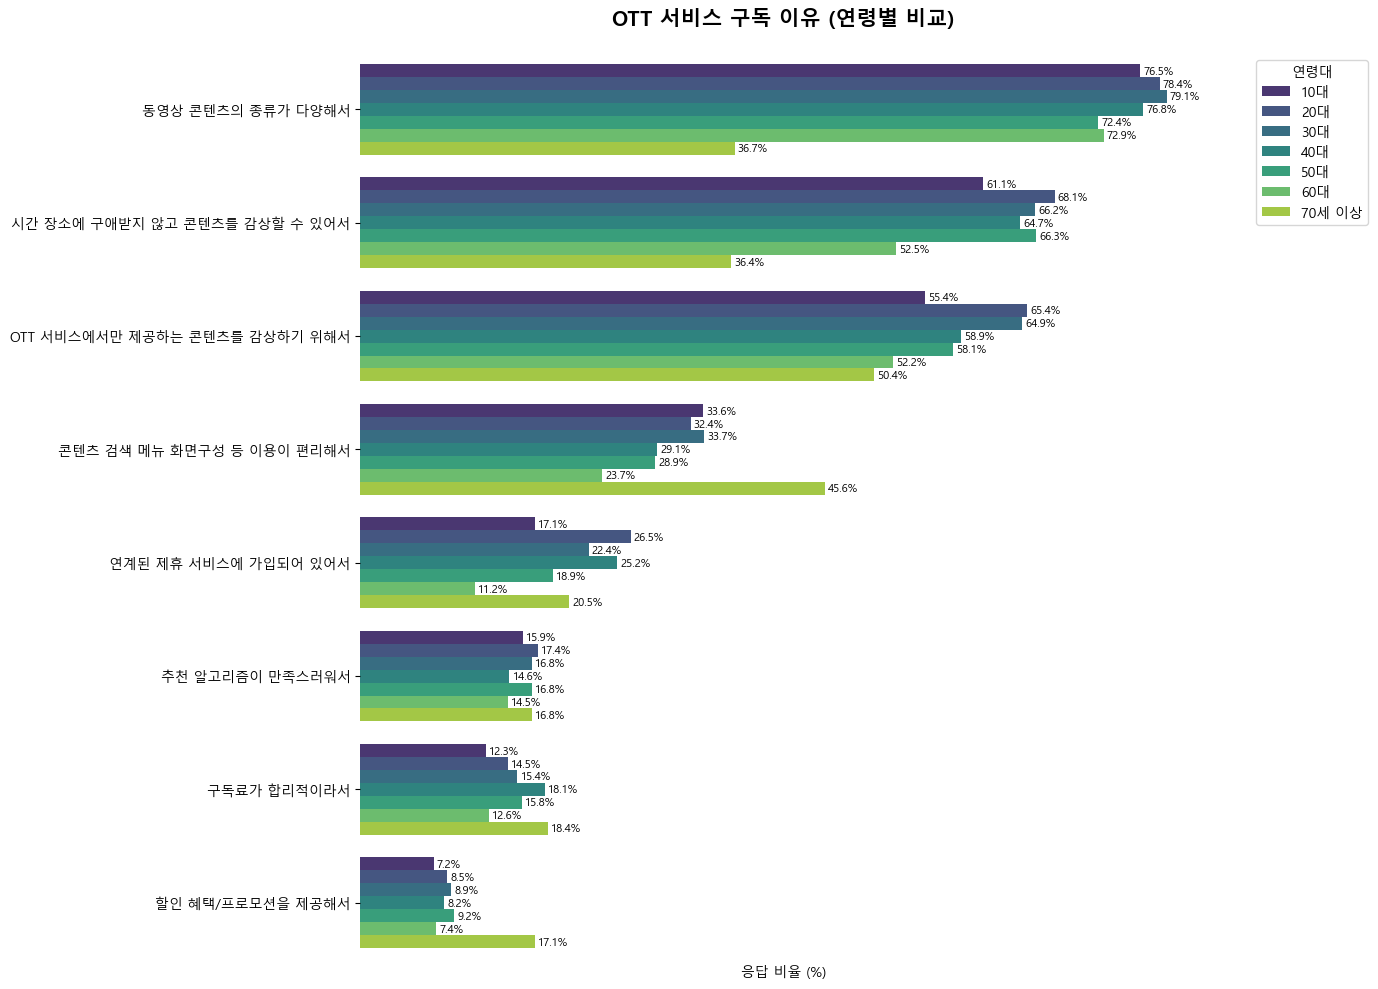

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 환경 (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기 (두 번째 줄을 헤더로 인식)
file_path = 'OTT_구독_이유_복수응답__20260409190433.csv'

try:
    df = pd.read_csv(file_path, header=1, encoding='utf-8-sig')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, header=1, encoding='cp949')

# 3. 데이터 전처리 (공백 제거 및 라벨 정리)
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# 시각화에서 제외할 컬럼 목록
base_cols = ['특성별(1)', '특성별(2)', '사례수 (명)']
genre_cols = [col for col in df.columns if col not in base_cols and '기타' not in col]

def get_melted_df(df_filtered, group_col):
    """필터링된 데이터를 시각화용으로 변환하는 함수"""
    df_plot = df_filtered[base_cols + genre_cols].copy()
    df_plot['구분'] = df_filtered[group_col]
    
    # Melt 변환
    df_melted = df_plot.melt(id_vars='구분', value_vars=genre_cols, var_name='구독 이유', value_name='비율(%)')
    
    # 라벨 정리
    df_melted['구독 이유'] = df_melted['구독 이유'].str.replace(r' \(\%\)', '', regex=True).str.replace(' (%)', '', regex=False)
    return df_melted

# --- [그래프 1: 성별 비교] ---
df_gender = df[df['특성별(1)'].str.contains('성별', na=False)].copy()
if not df_gender.empty:
    df_melted_gender = get_melted_df(df_gender, '특성별(2)')
    
    plt.figure(figsize=(12, 8))
    ax1 = sns.barplot(data=df_melted_gender, x='비율(%)', y='구독 이유', hue='구분', palette='Pastel1')
    
    # 수치 표기
    for p in ax1.patches:
        width = p.get_width()
        if width > 0:
            ax1.text(width + 0.5, p.get_y() + p.get_height()/2, f'{width:.1f}%', va='center', fontsize=9, fontweight='bold')
            
    plt.title('OTT 서비스 구독 이유 (성별 비교)', fontsize=15, pad=20, fontweight='bold')
    plt.xlabel('응답 비율 (%)')
    plt.ylabel('')
    plt.legend(title='성별', loc='lower right')
    sns.despine(left=True, bottom=True)
    ax1.set_xticks([])
    plt.tight_layout()
    plt.show()

# --- [그래프 2: 연령별 비교] ---
df_age = df[df['특성별(1)'].str.contains('연령', na=False)].copy()
if not df_age.empty:
    df_melted_age = get_melted_df(df_age, '특성별(2)')
    
    # 연령대의 경우 항목이 많으므로 더 큰 사이즈로 설정
    plt.figure(figsize=(14, 10))
    ax2 = sns.barplot(data=df_melted_age, x='비율(%)', y='구독 이유', hue='구분', palette='viridis')
    
    # 수치 표기
    for p in ax2.patches:
        width = p.get_width()
        if width > 0:
            ax2.text(width + 0.3, p.get_y() + p.get_height()/2, f'{width:.1f}%', va='center', fontsize=8)
            
    plt.title('OTT 서비스 구독 이유 (연령별 비교)', fontsize=15, pad=20, fontweight='bold')
    plt.xlabel('응답 비율 (%)')
    plt.ylabel('')
    
    # 범례를 그래프 밖으로 이동
    plt.legend(title='연령대', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    sns.despine(left=True, bottom=True)
    ax2.set_xticks([])
    plt.tight_layout()
    plt.show()
else:
    print("Warning: 연령별 데이터를 찾을 수 없습니다.")

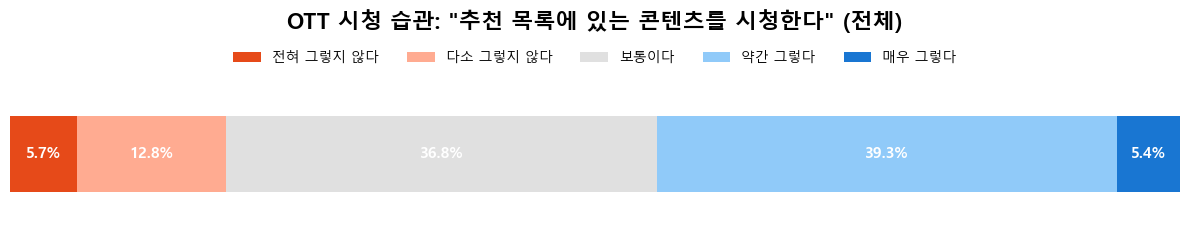

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 환경 (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기 (두 번째 줄을 헤더로 인식)
file_path = '유료_구독형_OTT_시청_습관__추천_목록에_있는_콘텐츠를_시청한다_20260409170012.csv'

try:
    df = pd.read_csv(file_path, header=1, encoding='utf-8-sig')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, header=1, encoding='cp949')

# 3. '전체' 데이터 추출 및 전처리
# '특성별(1)'이 '전체'인 행만 가져옵니다.
df_total = df[df['특성별(1)'] == '전체'].copy()

# 시각화에 필요한 척도 항목들만 선택
scale_cols = [
    '전혀 그렇지 않다 (%)', 
    '다소 그렇지 않다 (%)', 
    '보통이다 (%)', 
    '약간 그렇다 (%)', 
    '매우 그렇다 (%)'
]
df_plot = df_total[scale_cols]
df_plot.index = ['전체']

# 4. 그래프 그리기 설정
# 척도에 어울리는 순차적인 색상 팔레트 (빨간색 계열 -> 파란색 계열)
colors = ['#E64A19', '#FFAB91', '#E0E0E0', '#90CAF9', '#1976D2']

fig, ax = plt.subplots(figsize=(12, 2.5))

# 누적 가로 막대 그래프 생성
df_plot.plot(kind='barh', stacked=True, color=colors, ax=ax, width=0.5)

# 5. 그래프 디자인 및 꾸미기
# X축 범위를 0 ~ 100%로 설정
ax.set_xlim(0, 100)

# 막대 안에 수치(텍스트) 표기
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    
    # 너비가 3%보다 클 때만 수치 표시 (겹침 방지)
    if width > 3:
        ax.text(x + width / 2, 
                y + height / 2, 
                f'{width:.1f}%', 
                ha='center', 
                va='center', 
                fontsize=11, 
                fontweight='bold',
                color='white' if width > 20 or x > 70 or x < 10 else 'black')

# 축 및 테두리 제거하여 깔끔하게 표시
ax.set_ylabel('')
ax.set_xticks([])
ax.set_yticks([])
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(False)

# 제목 및 범례 설정
plt.title('OTT 시청 습관: "추천 목록에 있는 콘텐츠를 시청한다" (전체)', fontsize=16, pad=35, fontweight='bold')

# 항목 라벨에서 (%) 제거하여 범례 깔끔하게 표기
legend_labels = [col.replace(' (%)', '') for col in scale_cols]
ax.legend(legend_labels, loc='upper center', bbox_to_anchor=(0.5, 1.25), 
          ncol=5, frameon=False, fontsize=10)

plt.tight_layout()
plt.show()

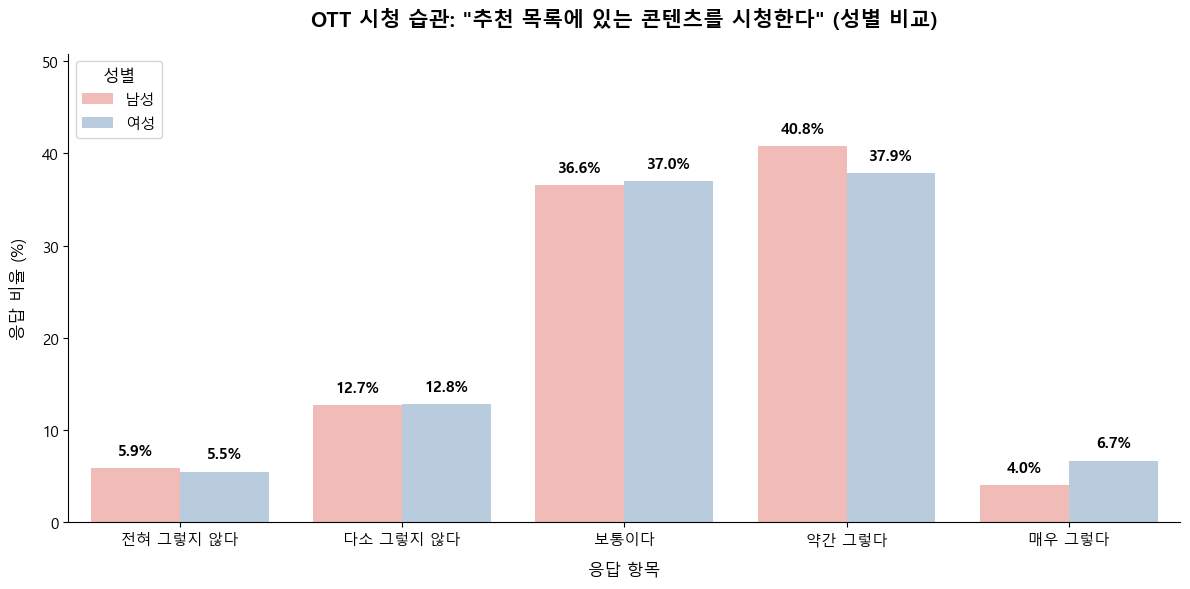

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 환경 (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기 (두 번째 줄을 헤더로 인식)
file_path = '유료_구독형_OTT_시청_습관__추천_목록에_있는_콘텐츠를_시청한다_20260409170012.csv'

try:
    df = pd.read_csv(file_path, header=1, encoding='utf-8-sig')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, header=1, encoding='cp949')

# 3. '성별' 데이터 추출 및 전처리
# '특성별(1)'이 '성별'인 행만 가져옵니다.
df_gender = df[df['특성별(1)'] == '성별'].copy()

# 5점 척도 항목과 성별 구분 컬럼 선택
scale_columns = [
    '특성별(2)', # 성별 (남성, 여성)
    '전혀 그렇지 않다 (%)', 
    '다소 그렇지 않다 (%)', 
    '보통이다 (%)', 
    '약간 그렇다 (%)', 
    '매우 그렇다 (%)'
]
df_plot = df_gender[scale_columns]

# 시각화를 위해 가로 데이터를 세로로 변환 (Melt)
df_melted = df_plot.melt(id_vars='특성별(2)', var_name='응답', value_name='비율(%)')

# 컬럼명 정리
df_melted.rename(columns={'특성별(2)': '성별'}, inplace=True)

# X축 라벨이 깔끔하게 보이도록 문자열 끝의 ' (%)' 텍스트 제거
df_melted['응답'] = df_melted['응답'].str.replace(' \(%\)', '', regex=True).str.replace(' (%)', '', regex=False)

# 4. 그래프 그리기 설정
plt.figure(figsize=(12, 6)) # 비교 그래프이므로 너비를 조금 늘려줍니다.

# 막대 그래프 생성 (X축: 응답, 색상 구분: 성별)
ax = sns.barplot(data=df_melted, x='응답', y='비율(%)', hue='성별', palette='Pastel1')

# 5. 그래프 디자인 및 꾸미기
# Y축 범위를 여유롭게 설정 (최대값보다 약간 높게)
max_val = df_melted['비율(%)'].max()
ax.set_ylim(0, max_val + 10)

# 막대 위에 수치(텍스트) 표기
for p in ax.patches:
    height = p.get_height()
    if pd.notnull(height) and height > 0:
        ax.text(p.get_x() + p.get_width() / 2., 
                height + 1,  # 막대 위로 1만큼 띄워서 표시
                f'{height:.1f}%', 
                ha='center', 
                va='bottom', 
                fontsize=11, 
                fontweight='bold')

# 축 및 테두리 정리
plt.title('OTT 시청 습관: "추천 목록에 있는 콘텐츠를 시청한다" (성별 비교)', fontsize=15, pad=20, fontweight='bold')
plt.xlabel('응답 항목', fontsize=12, labelpad=10)
plt.ylabel('응답 비율 (%)', fontsize=12, labelpad=10)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# 범례 위치 조정
plt.legend(title='성별', title_fontsize=12, fontsize=11, loc='upper left')

# 위, 오른쪽 테두리 제거하여 깔끔하게 표시
sns.despine()

plt.tight_layout()
plt.show()

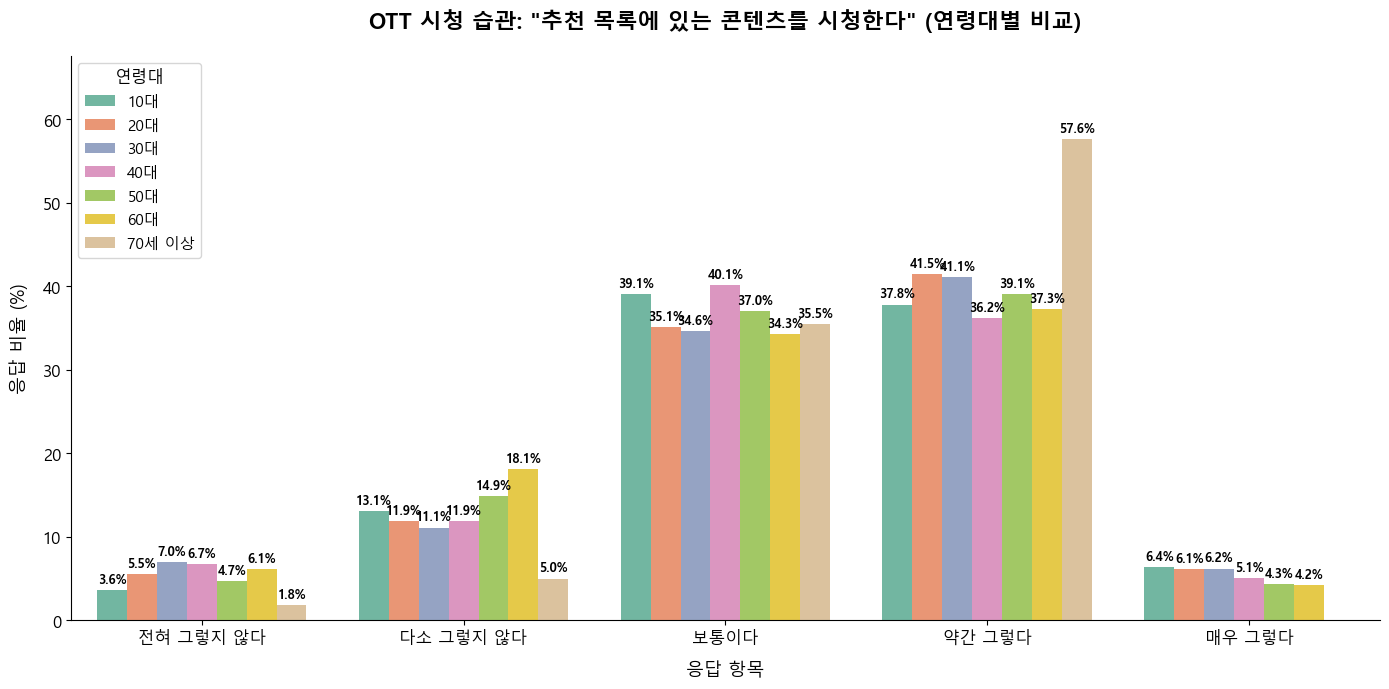

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 환경 (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기 (두 번째 줄을 헤더로 인식)
file_path = '유료_구독형_OTT_시청_습관__추천_목록에_있는_콘텐츠를_시청한다_20260409170012.csv'

try:
    df = pd.read_csv(file_path, header=1, encoding='utf-8-sig')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, header=1, encoding='cp949')

# 3. '연령' 데이터 추출 및 전처리
# '특성별(1)'이 '연령'인 행만 가져옵니다.
df_age = df[df['특성별(1)'] == '연령'].copy()

# 5점 척도 항목과 연령 구분 컬럼 선택
scale_columns = [
    '특성별(2)', # 연령대 (10대 ~ 70세 이상)
    '전혀 그렇지 않다 (%)', 
    '다소 그렇지 않다 (%)', 
    '보통이다 (%)', 
    '약간 그렇다 (%)', 
    '매우 그렇다 (%)'
]
df_plot = df_age[scale_columns]

# 시각화를 위해 가로 데이터를 세로로 변환 (Melt)
df_melted = df_plot.melt(id_vars='특성별(2)', var_name='응답', value_name='비율(%)')

# 컬럼명 정리
df_melted.rename(columns={'특성별(2)': '연령대'}, inplace=True)

# X축 라벨이 깔끔하게 보이도록 문자열 끝의 ' (%)' 텍스트 제거
df_melted['응답'] = df_melted['응답'].str.replace(' \(%\)', '', regex=True).str.replace(' (%)', '', regex=False)

# 4. 그래프 그리기 설정
plt.figure(figsize=(14, 7)) # 연령대 항목이 많아 너비를 충분히 늘려줍니다.

# 막대 그래프 생성 (X축: 응답, 색상 구분: 연령대)
ax = sns.barplot(data=df_melted, x='응답', y='비율(%)', hue='연령대', palette='Set2')

# 5. 그래프 디자인 및 꾸미기
# Y축 범위를 여유롭게 설정 (최대값보다 약간 높게)
max_val = df_melted['비율(%)'].max()
ax.set_ylim(0, max_val + 10)

# 막대 위에 수치(텍스트) 표기
for p in ax.patches:
    height = p.get_height()
    if pd.notnull(height) and height > 0:
        ax.text(p.get_x() + p.get_width() / 2., 
                height + 0.5,  # 텍스트가 겹치지 않도록 간격 조정
                f'{height:.1f}%', 
                ha='center', 
                va='bottom', 
                fontsize=9,  # 막대가 많아 폰트 크기를 약간 줄임
                fontweight='bold')

# 축 및 테두리 정리
plt.title('OTT 시청 습관: "추천 목록에 있는 콘텐츠를 시청한다" (연령대별 비교)', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('응답 항목', fontsize=13, labelpad=10)
plt.ylabel('응답 비율 (%)', fontsize=13, labelpad=10)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# 범례 위치 조정
plt.legend(title='연령대', title_fontsize=12, fontsize=11, loc='upper left')

# 위, 오른쪽 테두리 제거하여 깔끔하게 표시
sns.despine()

plt.tight_layout()
plt.show()

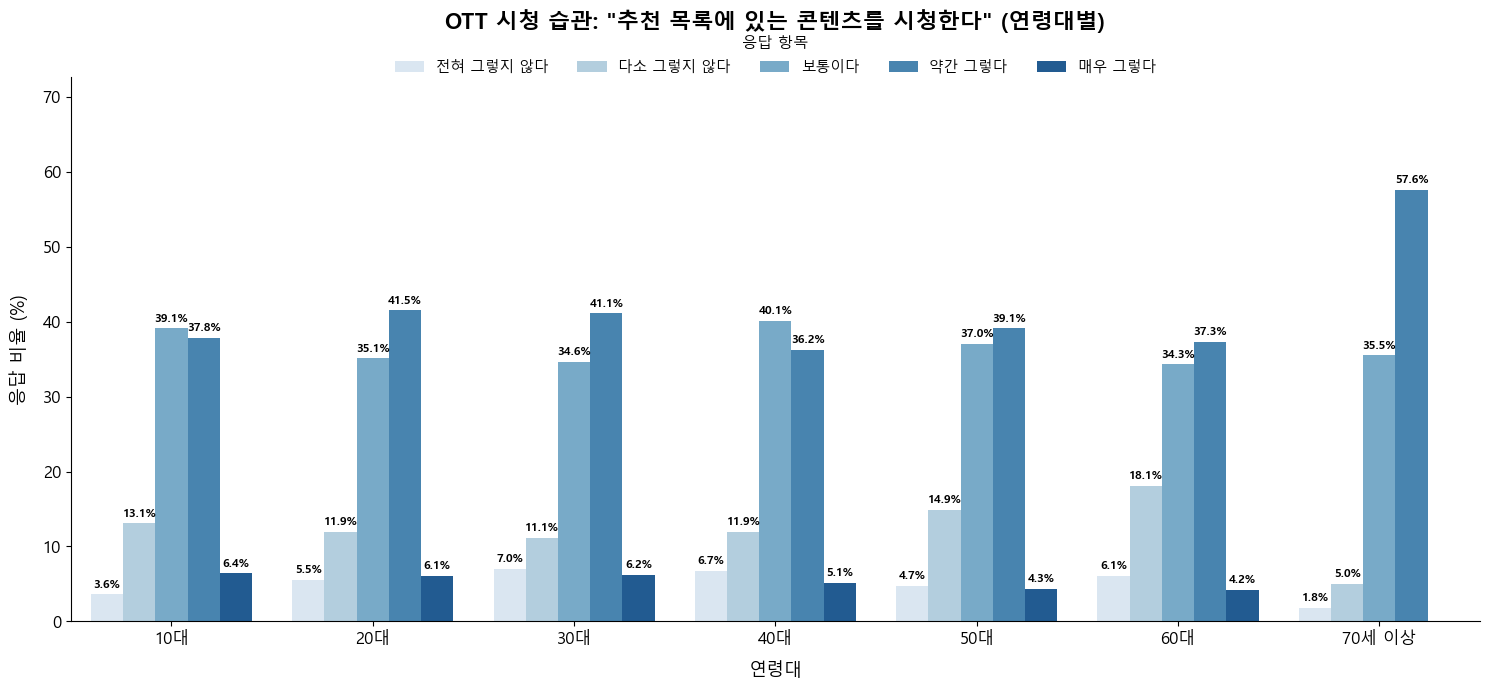

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 환경 (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기 (두 번째 줄을 헤더로 인식)
file_path = '유료_구독형_OTT_시청_습관__추천_목록에_있는_콘텐츠를_시청한다_20260409170012.csv'

try:
    df = pd.read_csv(file_path, header=1, encoding='utf-8-sig')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, header=1, encoding='cp949')

# 3. '연령' 데이터 추출 및 전처리
# '특성별(1)'이 '연령'인 행만 가져옵니다.
df_age = df[df['특성별(1)'] == '연령'].copy()

# 5점 척도 항목과 연령 구분 컬럼 선택
scale_columns = [
    '특성별(2)', # 연령대 (10대 ~ 70세 이상)
    '전혀 그렇지 않다 (%)', 
    '다소 그렇지 않다 (%)', 
    '보통이다 (%)', 
    '약간 그렇다 (%)', 
    '매우 그렇다 (%)'
]
df_plot = df_age[scale_columns]

# 시각화를 위해 가로 데이터를 세로로 변환 (Melt)
df_melted = df_plot.melt(id_vars='특성별(2)', var_name='응답', value_name='비율(%)')

# 컬럼명 정리
df_melted.rename(columns={'특성별(2)': '연령대'}, inplace=True)

# X축 라벨이 깔끔하게 보이도록 문자열 끝의 ' (%)' 텍스트 제거
df_melted['응답'] = df_melted['응답'].str.replace(' \(%\)', '', regex=True).str.replace(' (%)', '', regex=False)

# 4. 그래프 그리기 설정
plt.figure(figsize=(15, 7)) # 연령대 그룹 내에 5개의 막대가 들어가므로 너비를 넓게 설정합니다.

# 막대 그래프 생성 (X축: 연령대, 색상 구분: 응답)
# 5점 척도이므로 순차적인 느낌을 주는 'Blues' 팔레트 적용
ax = sns.barplot(data=df_melted, x='연령대', y='비율(%)', hue='응답', palette='Blues')

# 5. 그래프 디자인 및 꾸미기
# 범례와 텍스트가 겹치지 않도록 Y축 범위를 더 넉넉하게 설정
max_val = df_melted['비율(%)'].max()
ax.set_ylim(0, max_val + 15)

# 막대 위에 수치(텍스트) 표기
for p in ax.patches:
    height = p.get_height()
    if pd.notnull(height) and height > 0:
        ax.text(p.get_x() + p.get_width() / 2., 
                height + 0.5,  # 텍스트가 겹치지 않도록 간격 조정
                f'{height:.1f}%', 
                ha='center', 
                va='bottom', 
                fontsize=8.5,  # 막대가 많아 폰트 크기를 약간 줄임
                fontweight='bold',
                rotation=0) # 숫자가 잘 보이게 가로 방향 유지

# 축 및 테두리 정리
plt.title('OTT 시청 습관: "추천 목록에 있는 콘텐츠를 시청한다" (연령대별)', fontsize=16, pad=35, fontweight='bold')
plt.xlabel('연령대', fontsize=13, labelpad=10)
plt.ylabel('응답 비율 (%)', fontsize=13, labelpad=10)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# 범례 위치 조정 (그래프 위쪽 중앙에 가로로 배치하여 공간 확보)
plt.legend(title='응답 항목', loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=5, frameon=False, fontsize=10.5, title_fontsize=11)

# 위, 오른쪽 테두리 제거하여 깔끔하게 표시
sns.despine()

plt.tight_layout()
plt.show()